In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report



In [2]:
# %% Carregar datasets já divididos
train_df = pd.read_csv("data/train.csv")
val_df   = pd.read_csv("data/val.csv")
test_df  = pd.read_csv("data/test.csv")

In [3]:

target = "TriageGrade"

y_test = val_df[target]


In [4]:
def evaluate_model(model,X,y):
    preds = model.predict(X)

    return {
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds, average="weighted"),
        "recall": recall_score(y, preds, average="weighted"),
        "f1": f1_score(y, preds, average="weighted"),
        "preds": preds
    }


In [5]:
'''#Texto tirado do titanic
# Plot Precision-Recall Curve

def plot_pr_curve(y, probas, name):
    p, r, _ = precision_recall_curve(y, probas)
    plt.plot(r, p, label=name)'''

'#Texto tirado do titanic\n# Plot Precision-Recall Curve\n\ndef plot_pr_curve(y, probas, name):\n    p, r, _ = precision_recall_curve(y, probas)\n    plt.plot(r, p, label=name)'

In [6]:
def plot_cm(y, preds, name):
    cm = confusion_matrix(y, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [7]:
def multiclass_auc(y, probas):
    classes = np.unique(y)
    y_bin = label_binarize(y, classes=classes)

    return roc_auc_score(
        y_bin,
        probas,
        average="macro",
        multi_class="ovr"
    )

C:\Users\biamm\PycharmProjects\ProjetoAI\.venv4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


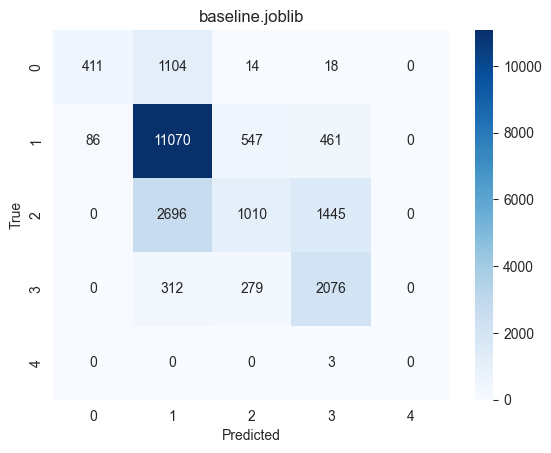

              precision    recall  f1-score   support

           1       0.83      0.27      0.40      1547
           2       0.73      0.91      0.81     12164
           3       0.55      0.20      0.29      5151
           4       0.52      0.78      0.62      2667
           5       0.00      0.00      0.00         3

    accuracy                           0.68     21532
   macro avg       0.52      0.43      0.42     21532
weighted avg       0.67      0.68      0.63     21532



C:\Users\biamm\PycharmProjects\ProjetoAI\.venv4\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'T82.4'

In [8]:
models_to_test = [
    "models/models/baseline.joblib",
    "models/models/decision_tree.joblib",
    "models/models/modelo_logreg_multi.joblib"]

auc_results = []
results =[]
for path in models_to_test:
    data = joblib.load(path)

    model = data["model"]
    features = data["features"]

    name = path.split("/")[-1]

    X_test =val_df[features]

    X_test_model = X_test[features]

    preds = model.predict(X_test_model)
    probas = model.predict_proba(X_test_model)
    auc = multiclass_auc(y_test, probas)
    out = evaluate_model(model, X_test_model, y_test)

    results.append({
        "model": name,
        "accuracy": out["accuracy"],
        "precision": out["precision"],
        "recall": out["recall"],
        "f1": out["f1"] })

    auc_results.append({
        "model": name,
        "auc_macro_ovr": auc})

    plot_cm(y_test, out["preds"], name)
    print(classification_report(y_test, preds, zero_division=0))



In [ ]:
df_results = pd.DataFrame(results)
df_results.sort_values("f1", ascending=False)


![image.png](attachment:351d9078-8554-483e-b5e5-29dfaf98dd76.png)

Rules of thumb
Consequences of choosing a high decision threshold

If you only make a prediction when the model is absolutely certain:

Your precision will be higher because you are only classifying as positive when you are certain (i.e. you are decreasing your FP)
Your recall will be lower because you are missing out on a lot of positives (i.e. you are increasing your FN: False Negatives)
you decrease your FPs (good) at the cost of increasing False Negatives (bad)

Consequences of having a low decision threshold

If you make positive predictions with a relatively low decision threshold:

Your recall will be higher. Since you are classifying more things as positive, you are more likely to find more Positives than you were before (you are increasing your TP: True Positives)
Your precision will be lower because you are increasing your Positives indiscriminately and in an imbalanced dataset, you are more likely to include False Positives doing that than True Positives (i.e. you are increasing your FP).
you increase your TPs (good) at the cost of FP (bad)
In the end what should you optimize for? If we go full precision-mode we are sacrificing recall and if we go full-recall model we sacrifice precision.

![image.png](attachment:fb198d7f-48c8-4622-9912-ba0b54a19104.png)

![image.png](attachment:48c61023-eb51-4d7e-9798-e6a141c3b754.png)

In [ ]:
'''results = []
for decision_threshold in ths:
    th_preds = (probas > decision_threshold).astype(int)

    recall = recall_score(y_val, th_preds)
    precision = precision_score(y_val, th_preds)

    results.append({"decision_threshold":decision_threshold,"recall":recall,"precision":precision})

results = pd.DataFrame(results).set_index('decision_threshold')
results
results.plot()'''
'''f1_score = lambda y_true, y_pred: 2 * precision_score(y_true, y_pred) * recall_score(y_true, y_pred) / (precision_score(y_true, y_pred) + recall_score(y_true, y_pred))


f1_score(y_val, preds)'''